In [ ]:
import numpy as np
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import time
from concurrent.futures import ProcessPoolExecutor, as_completed
import pickle

In [ ]:
dimensions = [3, 5, 10] # dimension
N = 2000 # support size of base measures
sample_sizes = np.arange(10,101,10)
T = 100 # number of iterations per sample size

In [ ]:
with open('NN_errors_plot1_23510_12pm.pkl', 'rb') as f:
    NN_E1_errors_1, NN_L1_errors_1 = pickle.load(f)

with open('rounding_errors_plot1_23510_1pm.pkl', 'rb') as f:
    rounding_errors_1 = pickle.load(f)

with open('NN_errors_plot2_23510_12pm.pkl', 'rb') as f:
    NN_E1_errors_2, NN_L1_errors_2 = pickle.load(f)

with open('rounding_errors_plot2_23510_12pm.pkl', 'rb') as f:
    rounding_errors_2 = pickle.load(f)

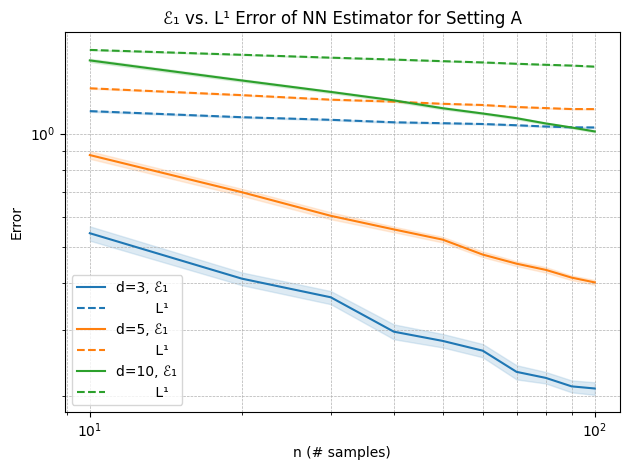

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = sample_sizes
colors = plt.cm.tab10.colors  # or use any colormap you like

def bootstrap_percentiles(data, q_low=10, q_high=90, n_bootstrap=1000):
    percentiles = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=len(data), replace=True)
        percentiles.append(np.mean(sample))
    return np.percentile(percentiles, [q_low, q_high])

for i, d in enumerate(dimensions):
    color = colors[i % len(colors)]
    light_color = tuple(c + (1 - c) * 0.5 for c in color)  # lighter color

    y_mean = []
    y_low = []
    y_high = []

    y2_mean = []
    y2_low = []
    y2_high = []

    for n in sample_sizes:
        vals_y = NN_E1_errors_1[(d, n)]
        q10, q90 = bootstrap_percentiles(vals_y)
        y_mean.append(np.mean(vals_y))
        y_low.append(q10)
        y_high.append(q90)

        vals_y2 = NN_L1_errors_1[(d, n)]
        q10_2, q90_2 = bootstrap_percentiles(vals_y2)
        y2_mean.append(np.mean(vals_y2))
        y2_low.append(q10_2)
        y2_high.append(q90_2)

    # E1 line + error band
    plt.plot(x, y_mean, label=f'd={d}, ℰ₁', color=color)
    plt.fill_between(x, y_low, y_high, color=light_color, alpha=0.3)

    # L1 line + error band
    plt.plot(x, y2_mean, '--', label=f'         L¹', color=color)
    plt.fill_between(x, y2_low, y2_high, color=light_color, alpha=0.3)

plt.xscale('log')
plt.yscale('log')

plt.xlabel('n (# samples)')
plt.ylabel('Error')
plt.legend()
plt.title('ℰ₁ vs. L¹ Error of NN Estimator for Setting A')
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.tight_layout()
plt.show()

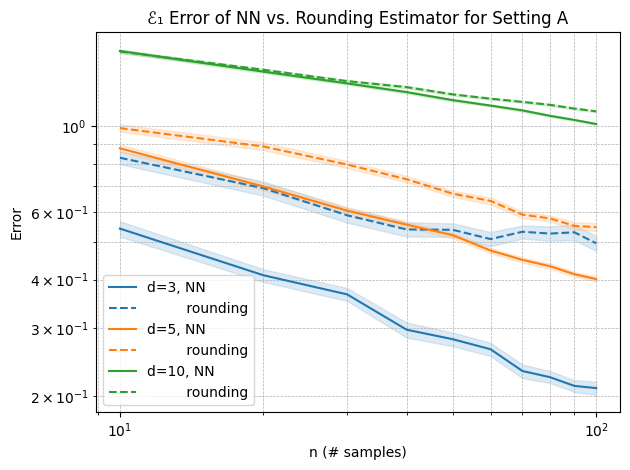

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = sample_sizes
colors = plt.cm.tab10.colors  # or use any colormap you like

for i, d in enumerate(dimensions):
    color = colors[i % len(colors)]
    light_color = tuple(c + (1 - c) * 0.5 for c in color)  # lighter color

    y_mean = []
    y_low = []
    y_high = []

    y2_mean = []
    y2_low = []
    y2_high = []

    for n in sample_sizes:
        vals_y = NN_E1_errors_1[(d, n)]
        q10, q90 = bootstrap_percentiles(vals_y)
        y_mean.append(np.mean(vals_y))
        y_low.append(q10)
        y_high.append(q90)

        vals_y2 = rounding_errors_1[(d, n)]
        q10_2, q90_2 = bootstrap_percentiles(vals_y2)
        y2_mean.append(np.mean(vals_y2))
        y2_low.append(q10_2)
        y2_high.append(q90_2)

    # NN line + error band
    plt.plot(x, y_mean, label=f'd={d}, NN', color=color)
    plt.fill_between(x, y_low, y_high, color=light_color, alpha=0.3)

    # rounding line + error band
    plt.plot(x, y2_mean, '--', label=f'         rounding', color=color)
    plt.fill_between(x, y2_low, y2_high, color=light_color, alpha=0.3)

plt.xscale('log')
plt.yscale('log')

plt.xlabel('n (# samples)')
plt.ylabel('Error')
plt.legend()
plt.title('ℰ₁ Error of NN vs. Rounding Estimator for Setting A')
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.tight_layout()
plt.show()

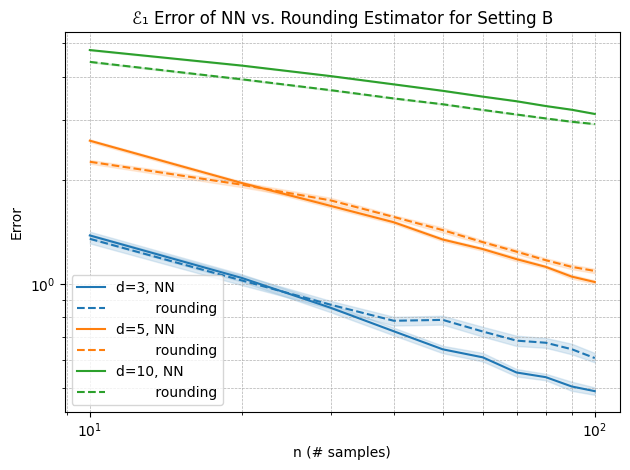

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = sample_sizes
colors = plt.cm.tab10.colors  # or use any colormap you like

for i, d in enumerate(dimensions):
    color = colors[i % len(colors)]
    light_color = tuple(c + (1 - c) * 0.5 for c in color)  # lighter color

    y_mean = []
    y_low = []
    y_high = []

    y2_mean = []
    y2_low = []
    y2_high = []

    for n in sample_sizes:
        vals_y = NN_E1_errors_2[(d, n)]
        q10, q90 = bootstrap_percentiles(vals_y)
        y_mean.append(np.mean(vals_y))
        y_low.append(q10)
        y_high.append(q90)

        vals_y2 = rounding_errors_2[(d, n)]
        q10_2, q90_2 = bootstrap_percentiles(vals_y2)
        y2_mean.append(np.mean(vals_y2))
        y2_low.append(q10_2)
        y2_high.append(q90_2)

    # NN line + error band
    plt.plot(x, y_mean, label=f'd={d}, NN', color=color)
    plt.fill_between(x, y_low, y_high, color=light_color, alpha=0.3)

    # rounding line + error band
    plt.plot(x, y2_mean, '--', label=f'         rounding', color=color)
    plt.fill_between(x, y2_low, y2_high, color=light_color, alpha=0.3)

plt.xscale('log')
plt.yscale('log')

plt.xlabel('n (# samples)')
plt.ylabel('Error')
plt.legend()
plt.title('ℰ₁ Error of NN vs. Rounding Estimator for Setting B')
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.tight_layout()
plt.show()

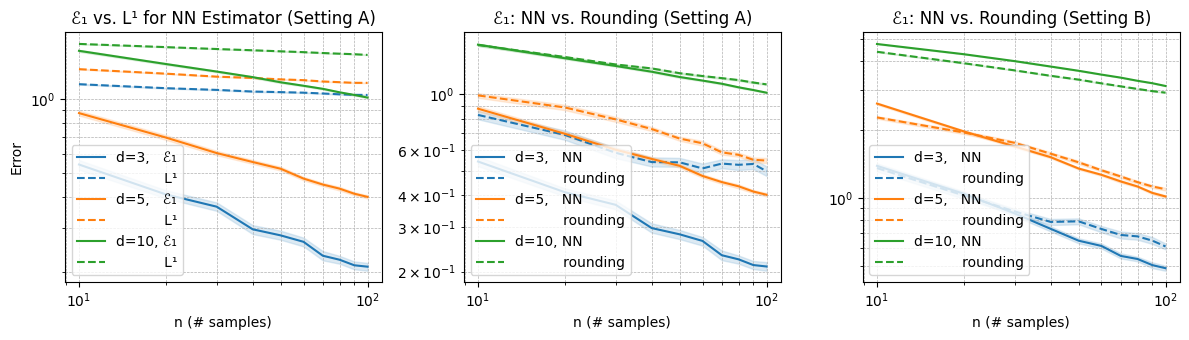

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FixedLocator, FixedFormatter

x = sample_sizes
colors = plt.cm.tab10.colors  # or any colormap

def bootstrap_percentiles(data, q_low=10, q_high=90, n_bootstrap=1000):
    percentiles = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=len(data), replace=True)
        percentiles.append(np.mean(sample))
    return np.percentile(percentiles, [q_low, q_high])

fig, axs = plt.subplots(1, 3, figsize=(12, 3.5), sharey=False)

# --- Subplot 1: NN Estimator ℰ₁ vs L¹ ---
for i, d in enumerate(dimensions):
    color = colors[i % len(colors)]
    light_color = tuple(c + (1 - c) * 0.5 for c in color)

    y_mean, y_low, y_high = [], [], []
    y2_mean, y2_low, y2_high = [], [], []

    for n in sample_sizes:
        vals_y = NN_E1_errors_1[(d, n)]
        q10, q90 = bootstrap_percentiles(vals_y)
        y_mean.append(np.mean(vals_y))
        y_low.append(q10)
        y_high.append(q90)

        vals_y2 = NN_L1_errors_1[(d, n)]
        q10_2, q90_2 = bootstrap_percentiles(vals_y2)
        y2_mean.append(np.mean(vals_y2))
        y2_low.append(q10_2)
        y2_high.append(q90_2)

    axs[0].plot(x, y_mean, label=f'd={d},{'  ' if i < 2 else ''} ℰ₁', color=color)
    axs[0].fill_between(x, y_low, y_high, color=light_color, alpha=0.3)
    axs[0].plot(x, y2_mean, '--', label=f'           L¹', color=color)
    axs[0].fill_between(x, y2_low, y2_high, color=light_color, alpha=0.3)

axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].set_title('ℰ₁ vs. L¹ for NN Estimator (Setting A)')
axs[0].set_xlabel('n (# samples)')
axs[0].set_ylabel('Error')
axs[0].grid(True, which="both", ls="--", linewidth=0.5)
axs[0].legend()

# --- Subplot 2: NN vs Rounding (Setting A) ---
for i, d in enumerate(dimensions):
    color = colors[i % len(colors)]
    light_color = tuple(c + (1 - c) * 0.5 for c in color)

    y_mean, y_low, y_high = [], [], []
    y2_mean, y2_low, y2_high = [], [], []

    for n in sample_sizes:
        vals_y = NN_E1_errors_1[(d, n)]
        q10, q90 = bootstrap_percentiles(vals_y)
        y_mean.append(np.mean(vals_y))
        y_low.append(q10)
        y_high.append(q90)

        vals_y2 = rounding_errors_1[(d, n)]
        q10_2, q90_2 = bootstrap_percentiles(vals_y2)
        y2_mean.append(np.mean(vals_y2))
        y2_low.append(q10_2)
        y2_high.append(q90_2)

    axs[1].plot(x, y_mean, label=f'd={d}, {'  ' if i < 2 else ''}NN', color=color)
    axs[1].fill_between(x, y_low, y_high, color=light_color, alpha=0.3)
    axs[1].plot(x, y2_mean, '--', label=f'           rounding', color=color)
    axs[1].fill_between(x, y2_low, y2_high, color=light_color, alpha=0.3)

axs[1].set_xscale('log')
axs[1].set_yscale('log')
axs[1].set_title('ℰ₁: NN vs. Rounding (Setting A)')
axs[1].set_xlabel('n (# samples)')
axs[1].grid(True, which="both", ls="--", linewidth=0.5)
axs[1].legend()

# --- Subplot 3: NN vs Rounding (Setting B) ---
for i, d in enumerate(dimensions):
    color = colors[i % len(colors)]
    light_color = tuple(c + (1 - c) * 0.5 for c in color)

    y_mean, y_low, y_high = [], [], []
    y2_mean, y2_low, y2_high = [], [], []

    for n in sample_sizes:
        vals_y = NN_E1_errors_2[(d, n)]
        q10, q90 = bootstrap_percentiles(vals_y)
        y_mean.append(np.mean(vals_y))
        y_low.append(q10)
        y_high.append(q90)

        vals_y2 = rounding_errors_2[(d, n)]
        q10_2, q90_2 = bootstrap_percentiles(vals_y2)
        y2_mean.append(np.mean(vals_y2))
        y2_low.append(q10_2)
        y2_high.append(q90_2)

    axs[2].plot(x, y_mean, label=f'd={d}, {'  ' if i < 2 else ''}NN', color=color)
    axs[2].fill_between(x, y_low, y_high, color=light_color, alpha=0.3)
    axs[2].plot(x, y2_mean, '--', label=f'           rounding', color=color)
    axs[2].fill_between(x, y2_low, y2_high, color=light_color, alpha=0.3)

axs[2].set_xscale('log')
axs[2].set_yscale('log')
axs[2].set_title('ℰ₁: NN vs. Rounding (Setting B)')
axs[2].set_xlabel('n (# samples)')
axs[2].grid(True, which="both", ls="--", linewidth=0.5)
axs[2].legend()

plt.tight_layout()
plt.show()



In [54]:
fig.savefig('experiments.pdf')